In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc


In [7]:
# Load data
with np.load('/home/server/Projects/data/AKI/preop_trainable/unfiltered_andrew.npz', allow_pickle=True) as data:
    X_train = data["X_train"]
    X_test = data["X_test"]
    y_binary_train = data["y_binary_train"]
    y_binary_test = data["y_binary_test"]

In [8]:
# Define the XGBoost model
xgb_classifier = xgb.XGBClassifier(
    objective="binary:logistic",  # Binary classification (log loss)
    eval_metric="logloss",        # Logarithmic loss for better convergence
    use_label_encoder=False,      # Avoids unnecessary warnings
    n_estimators=1000,             # Number of boosting rounds
    learning_rate=0.1,            # Step size shrinkage
    max_depth=6,                  # Limits tree depth for regularization
    subsample=0.8,                # Prevents overfitting
    colsample_bytree=0.8,         # Reduces features per tree to avoid overfitting
    random_state=42
)

In [9]:
# Train the model
xgb_classifier.fit(X_train, y_binary_train)

/home/server/Projects/VitalDB-Dimensionality-Reduction/.venv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [05:33:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [10]:
# Predict binary labels
y_pred = xgb_classifier.predict(X_test)

# Classification Metrics
accuracy = accuracy_score(y_binary_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

cm = confusion_matrix(y_binary_test, y_pred)
print('Confusion Matrix:')
print(cm)

report = classification_report(y_binary_test, y_pred)
print('Classification Report:')
print(report)

Accuracy: 0.93
Confusion Matrix:
[[10718   303]
 [  486   212]]
Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.97      0.96     11021
        True       0.41      0.30      0.35       698

    accuracy                           0.93     11719
   macro avg       0.68      0.64      0.66     11719
weighted avg       0.92      0.93      0.93     11719



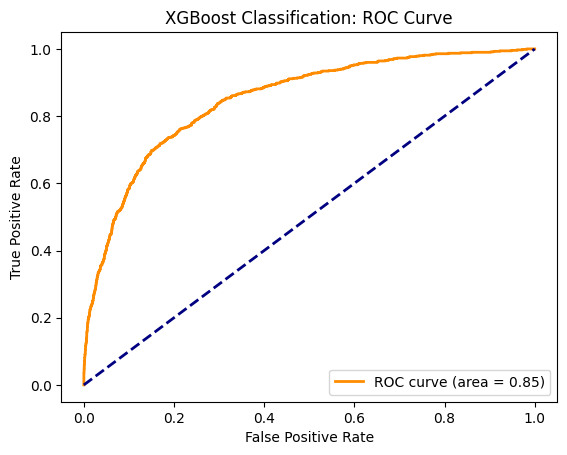

In [11]:
# Predict probabilities for ROC curve
y_prob = xgb_classifier.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_binary_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost Classification: ROC Curve')
plt.legend(loc='lower right')
plt.show()


# XGBoost Complete Script


XGBoost Classification:
Calculated scale_pos_weight: 1.00 (44080 negative / 44080 positive)
Training XGBoost model...


/home/server/Projects/VitalDB-Dimensionality-Reduction/.venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [17:39:32] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


('Precision', 0.50390625)
('Sensitivity', 0.18481375358166188)
('Accuracy', 0.9406041986687148)
('rc_auc', 0.784013047389742)
('pr_auc', 0.28804062301174493)
('Specificity', 0.9884754990925589)
('Negative Predictive Value', 0.9503577037166289)
('F1 Score', 0.27044025157232704)


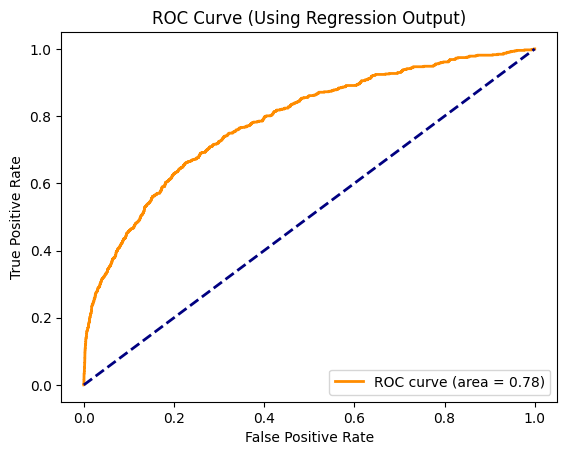

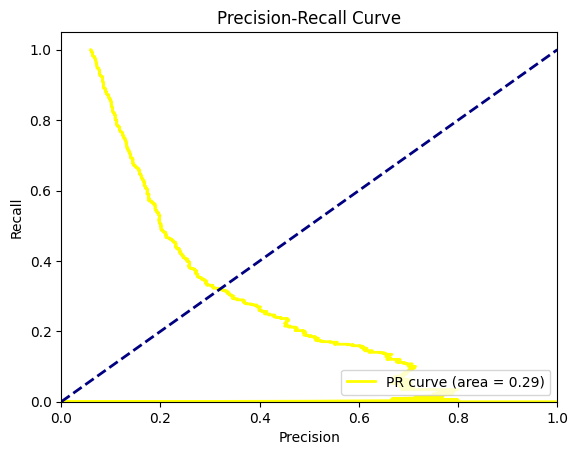

In [5]:
# this file cannot be called 'xgboost.py' or it interferes with the import

import numpy as np
import xgboost as xgb
# Assuming 'utils.py' and 'performance_dict' are in the same directory or accessible
# from utils import performance_dict # This line is commented out as 'utils' is not provided

file = "/home/server/Projects/data/AKI/tabular_intraop.npz"

# Load data
with np.load(file, allow_pickle=True) as data:
    X_train = data["X_train"]
    X_test = data["X_test"]
    y_binary_train = data["y_binary_train"]
    y_binary_test = data["y_binary_test"]

# -------------------- XGBoost Classification --------------------
print("\nXGBoost Classification:")

# Dynamically calculate scale_pos_weight for class balancing
num_negative = np.sum(y_binary_train == 0)
num_positive = np.sum(y_binary_train == 1)

if num_positive > 0:
    scale_pos_weight_calculated = num_negative / num_positive
    print(f"Calculated scale_pos_weight: {scale_pos_weight_calculated:.2f} ({num_negative} negative / {num_positive} positive)")
else:
    # Default to 1 if there are no positive samples to avoid division by zero
    # or handle this edge case as per your requirements
    scale_pos_weight_calculated = 1
    print("Warning: No positive samples found in y_binary_train. scale_pos_weight set to 1.")


# Define the XGBoost model
xgb_classifier = xgb.XGBClassifier(
    objective="binary:logistic",  # Binary classification (log loss)
    eval_metric="logloss",        # Logarithmic loss for better convergence
    use_label_encoder=False,      # Avoids unnecessary warnings
    n_estimators=1000,            # Number of boosting rounds
    learning_rate=0.1,            # Step size shrinkage
    max_depth=6,                  # Limits tree depth for regularization
    subsample=0.8,                # Prevents overfitting
    colsample_bytree=0.8,         # Reduces features per tree to avoid overfitting
    random_state=42,
    scale_pos_weight=scale_pos_weight_calculated  # Use the dynamically calculated weight
)

# Train the model
# Consider adding early stopping for better performance and to prevent overfitting
print("Training XGBoost model...")
xgb_classifier.fit(X_train, y_binary_train,
                   eval_set=[(X_test, y_binary_test)], # Optional: for early stopping and monitoring
                   verbose=False)                     # Optional: set to True or a number to see training progress


# Predict binary labels
y_pred = xgb_classifier.predict(X_test)
y_prob = xgb_classifier.predict_proba(X_test)[:, 1]

# Assuming performance_dict is defined elsewhere and handles printing/plotting
# For this example, I'll use a placeholder if performance_dict is not available.
try:
    from utils import performance_dict
    performance_dict(y_binary_test, y_pred, y_prob, bool_print=True, plot=True)
except ImportError:
    print("Skipping performance_dict: 'utils' module not found or 'performance_dict' not defined.")
    print(f"\nSample Predictions (first 10): {y_pred[:10]}")
    print(f"Sample Probabilities (first 10): {y_prob[:10]}")
    print(f"Sample Actual labels (first 10): {y_binary_test[:10]}")

    # Basic performance metrics as an alternative
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
    print(f"\nBasic Performance Metrics:")
    print(f"  Accuracy: {accuracy_score(y_binary_test, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_binary_test, y_pred, zero_division=0):.4f}")
    print(f"  Recall: {recall_score(y_binary_test, y_pred, zero_division=0):.4f}")
    print(f"  F1-score: {f1_score(y_binary_test, y_pred, zero_division=0):.4f}")
    print(f"  ROC AUC: {roc_auc_score(y_binary_test, y_prob):.4f}")

# HPO XGBoost

In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
import time

# --- Configuration ---
CSV_FILE_PATH = "/home/server/Projects/data/AKI/tabular_combined.csv" # Using the path from your script
TARGET_COLUMN_NAME = 'aki_boolean'

# HPO Settings
N_TRIALS = 30
CV_FOLDS = 3
RANDOM_STATE = 42
OPTIMIZATION_METRIC_NAME = 'balanced_accuracy'
TEST_SIZE_SPLIT = 0.2

print("IMPORTANT: This script uses 'device=cuda' and 'tree_method=hist' for XGBoost GPU training.")
print("Booster is fixed to 'gbtree' for faster HPO.")
print(f"XGBoost version being used: {xgb.__version__}")
print("-" * 30)

# --- Load Data from CSV and Prepare ---
print(f"Loading data from CSV: {CSV_FILE_PATH}")
try:
    df = pd.read_csv(CSV_FILE_PATH)
    print("CSV data loaded successfully.")

    if TARGET_COLUMN_NAME not in df.columns:
        print(f"ERROR: Target column '{TARGET_COLUMN_NAME}' not found in the CSV file.")
        print(f"Available columns are: {df.columns.tolist()}")
        exit()
    
    y = df[TARGET_COLUMN_NAME]
    X = df.drop(columns=[TARGET_COLUMN_NAME])

    if 'op_id' in X.columns:
        print("Dropping 'op_id' column from features.")
        X = X.drop(columns=['op_id'])

    print(f"Shape of features (X) from CSV (after potential ID drop): {X.shape}")
    print(f"Shape of target (y) from CSV: {y.shape}")
    print(f"Target value counts:\n{y.value_counts(normalize=True)}")

    X_all_train, X_test, y_all_train, y_binary_test = train_test_split(
        X, y,
        test_size=TEST_SIZE_SPLIT,
        random_state=RANDOM_STATE,
        stratify=y
    )
    
    X_all_train = X_all_train.values
    y_all_train = y_all_train.values
    X_test = X_test.values
    y_binary_test = y_binary_test.values

    print(f"X_all_train shape after split: {X_all_train.shape}, y_all_train shape after split: {y_all_train.shape}")
    print(f"X_test shape after split: {X_test.shape}, y_binary_test shape after split: {y_binary_test.shape}")

except FileNotFoundError:
    print(f"Error: The CSV file '{CSV_FILE_PATH}' was not found.")
    exit()
except Exception as e:
    print(f"An error occurred while loading or splitting data: {e}")
    exit()

# --- Calculate scale_pos_weight ---
num_negative_train = np.sum(y_all_train == 0)
num_positive_train = np.sum(y_all_train == 1)

if num_positive_train > 0:
    CALCULATED_SCALE_POS_WEIGHT = num_negative_train / num_positive_train
    print(f"Calculated scale_pos_weight for training: {CALCULATED_SCALE_POS_WEIGHT:.2f} ({num_negative_train} neg / {num_positive_train} pos)")
else:
    CALCULATED_SCALE_POS_WEIGHT = 1
    print("Warning: No positive samples found in y_all_train. scale_pos_weight set to 1.")


# --- Define the Objective Function for Optuna ---
def objective(trial: optuna.trial.Trial):
    print(f"\n--- Starting Trial {trial.number} ---")
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        # --- GPU Configuration (Modern Way for XGBoost 2.0.0+) ---
        'device': 'cuda', 
        'tree_method': 'hist', # Specify 'hist' when device is 'cuda'
        
        'booster': 'gbtree',  # Fixed to 'gbtree', removed 'dart' from suggestion
        
        'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'eta': trial.suggest_float('eta', 0.01, 0.3, log=True), # learning_rate
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1500),
        'scale_pos_weight': CALCULATED_SCALE_POS_WEIGHT,
        'random_state': RANDOM_STATE,
        'enable_categorical': False
    }

    # DART-specific parameters are removed as 'booster' is fixed to 'gbtree'
    # if params['booster'] == 'dart':
    #     ...

    cv_scores = []
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE + trial.number)
    # Updated print statement to reflect fixed booster
    print(f"  Trial {trial.number}: Starting {CV_FOLDS}-Fold CV (booster='gbtree', device='cuda', tree_method='hist')...")


    for fold, (train_idx, val_idx) in enumerate(skf.split(X_all_train, y_all_train)):
        print(f"    Trial {trial.number}, Fold {fold+1}/{CV_FOLDS}: Training model on GPU...")
        X_train_fold, X_val_fold = X_all_train[train_idx], X_all_train[val_idx]
        y_train_fold, y_val_fold = y_all_train[train_idx], y_all_train[val_idx]

        model = xgb.XGBClassifier(**params)
        try:
            model.fit(
                X_train_fold, y_train_fold,
                verbose=False
            )
        except xgb.core.XGBoostError as e:
            if "CUDA" in str(e) or "GPU" in str(e):
                print(f"    Trial {trial.number}, Fold {fold+1}: XGBoost GPU Error: {e}")
                print("    This likely means XGBoost GPU support is not available or configured correctly.")
                print("    Skipping this trial. Consider installing XGBoost with GPU support.")
                raise optuna.exceptions.TrialPruned("XGBoost GPU error")
            else:
                raise e

        preds_class = model.predict(X_val_fold)
        fold_score = balanced_accuracy_score(y_val_fold, preds_class)
        cv_scores.append(fold_score)
        print(f"    Trial {trial.number}, Fold {fold+1}/{CV_FOLDS}: {OPTIMIZATION_METRIC_NAME} = {fold_score:.4f}")

    mean_cv_score = np.mean(cv_scores)
    print(f"  Trial {trial.number}: Mean CV {OPTIMIZATION_METRIC_NAME} = {mean_cv_score:.4f}")
    print(f"--- Finished Trial {trial.number} ---")

    trial.report(mean_cv_score, step=0)
    if trial.should_prune():
        print(f"  Trial {trial.number}: Pruned by Optuna.")
        raise optuna.TrialPruned()

    return mean_cv_score


# --- Create and Run Optuna Study ---
# Updated print statement
print(f"\nStarting Optuna Hyperparameter Optimization (booster='gbtree', using device='cuda', tree_method='hist')...")
study = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0)
)

start_time = time.time()
try:
    study.optimize(objective, n_trials=N_TRIALS, timeout=None)
except optuna.exceptions.TrialPruned as e:
    if e.args and "XGBoost GPU error" in str(e.args[0]):
        print("\nOptimization included trials pruned due to XGBoost GPU errors.")
        print("Please check your XGBoost installation and CUDA setup if you intend to use GPU.")
    else:
        print(f"\nOptimization included pruned trials: {e}")
except Exception as e:
    print(f"Optimization stopped due to an unexpected error: {e}")
end_time = time.time()

print(f"Optuna HPO finished in {(end_time - start_time) / 60:.2f} minutes.")

# --- Display Best Results ---
print("\n--- Optuna HPO Results ---")
if len(study.trials) > 0:
    valid_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    if not valid_trials:
        print("No trials completed successfully. Cannot determine best parameters.")
    else:
        best_trial_obj = study.best_trial
        print(f"Best trial number: {best_trial_obj.number}")
        print(f"Best trial ({OPTIMIZATION_METRIC_NAME}): {best_trial_obj.value:.4f}")
        print("Best hyperparameters:")
        best_params_from_study = best_trial_obj.params # 'booster' will not be in here as it was fixed
        
        print(f"  booster: gbtree (fixed)") # Explicitly state the fixed booster
        for key, value in best_params_from_study.items():
            print(f"  {key}: {value}")

        # --- Train Final Model with Best Hyperparameters ---
        print("\nTraining final model with best hyperparameters on the full training data (using device='cuda', tree_method='hist')...")
        
        final_model_params = {
            'objective': 'binary:logistic',
            'eval_metric': 'auc',
            'device': 'cuda',
            'tree_method': 'hist', 
            'booster': 'gbtree', # Set explicitly for the final model
            # Retrieve other parameters from best_params_from_study
            'lambda': best_params_from_study.get('lambda'), # Use .get() for safety if any param was unexpectedly not tuned
            'alpha': best_params_from_study.get('alpha'),
            'subsample': best_params_from_study.get('subsample'),
            'colsample_bytree': best_params_from_study.get('colsample_bytree'),
            'max_depth': best_params_from_study.get('max_depth'),
            'min_child_weight': best_params_from_study.get('min_child_weight'),
            'eta': best_params_from_study.get('eta'),
            'gamma': best_params_from_study.get('gamma'),
            'n_estimators': best_params_from_study.get('n_estimators'),
            'scale_pos_weight': CALCULATED_SCALE_POS_WEIGHT,
            'random_state': RANDOM_STATE,
            'enable_categorical': False
        }
        # DART-specific parameters no longer needed for final_model_params

        final_model = xgb.XGBClassifier(**final_model_params)
        try:
            final_model.fit(X_all_train, y_all_train, verbose=False)
            print("Final model trained successfully on GPU.")

            y_pred_class_test = final_model.predict(X_test)
            y_prob_test = final_model.predict_proba(X_test)[:, 1]

            print("\nPerformance of the final model on the test set:")
            final_balanced_accuracy = balanced_accuracy_score(y_binary_test, y_pred_class_test)
            print(f"  Balanced Accuracy: {final_balanced_accuracy:.4f}")
            
            try:
                from utils import performance_dict
                print("  Using custom performance_dict:")
                performance_dict(y_binary_test, y_pred_class_test, y_prob_test, bool_print=True, plot=False)
            except ImportError:
                from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
                print(f"  ROC AUC: {roc_auc_score(y_binary_test, y_prob_test):.4f}")
                print(f"  Accuracy (overall): {accuracy_score(y_binary_test, y_pred_class_test):.4f}")
        except xgb.core.XGBoostError as e:
            if "CUDA" in str(e) or "GPU" in str(e):
                print("Error during final model training with GPU. Ensure XGBoost GPU support is correctly configured.")
            else:
                print(f"An unexpected XGBoost error occurred during final model training: {e}")
        except Exception as e:
            print(f"An unexpected error occurred during final model training or evaluation: {e}")
else:
    print("No trials were completed successfully, or study object is not as expected.")

print("\nOptuna HPO script completed.")

/home/server/Projects/VitalDB-Dimensionality-Reduction/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


IMPORTANT: This script uses 'device=cuda' and 'tree_method=hist' for XGBoost GPU training.
Booster is fixed to 'gbtree' for faster HPO.
XGBoost version being used: 3.0.2
------------------------------
Loading data from CSV: /home/server/Projects/data/AKI/tabular_combined.csv


[I 2025-05-31 23:13:29,766] A new study created in memory with name: no-name-ab32b400-0cbc-4682-8ff6-22c3a45ffeed


CSV data loaded successfully.
Dropping 'op_id' column from features.
Shape of features (X) from CSV (after potential ID drop): (60824, 274)
Shape of target (y) from CSV: (60824,)
Target value counts:
aki_boolean
False    0.955051
True     0.044949
Name: proportion, dtype: float64
X_all_train shape after split: (48659, 274), y_all_train shape after split: (48659,)
X_test shape after split: (12165, 274), y_binary_test shape after split: (12165,)
Calculated scale_pos_weight for training: 21.25 (46472 neg / 2187 pos)

Starting Optuna Hyperparameter Optimization (booster='gbtree', using device='cuda', tree_method='hist')...

--- Starting Trial 0 ---
  Trial 0: Starting 3-Fold CV (booster='gbtree', device='cuda', tree_method='hist')...
    Trial 0, Fold 1/3: Training model on GPU...


/home/server/Projects/VitalDB-Dimensionality-Reduction/.venv/lib/python3.10/site-packages/xgboost/core.py:729: UserWarning: [23:14:02] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


...

    Trial 27, Fold 3/3: balanced_accuracy = 0.8413
  Trial 27: Mean CV balanced_accuracy = 0.8434
--- Finished Trial 27 ---

--- Starting Trial 28 ---
  Trial 28: Starting 3-Fold CV (booster='gbtree', device='cuda', tree_method='hist')...
    Trial 28, Fold 1/3: Training model on GPU...
    Trial 28, Fold 1/3: balanced_accuracy = 0.7696
    Trial 28, Fold 2/3: Training model on GPU...
    Trial 28, Fold 2/3: balanced_accuracy = 0.7623
    Trial 28, Fold 3/3: Training model on GPU...


[I 2025-05-31 23:27:40,039] Trial 28 pruned. 


    Trial 28, Fold 3/3: balanced_accuracy = 0.7714
  Trial 28: Mean CV balanced_accuracy = 0.7678
--- Finished Trial 28 ---
  Trial 28: Pruned by Optuna.

--- Starting Trial 29 ---
  Trial 29: Starting 3-Fold CV (booster='gbtree', device='cuda', tree_method='hist')...
    Trial 29, Fold 1/3: Training model on GPU...
    Trial 29, Fold 1/3: balanced_accuracy = 0.8206
    Trial 29, Fold 2/3: Training model on GPU...
    Trial 29, Fold 2/3: balanced_accuracy = 0.8239
    Trial 29, Fold 3/3: Training model on GPU...


[I 2025-05-31 23:28:06,191] Trial 29 pruned. 


    Trial 29, Fold 3/3: balanced_accuracy = 0.8286
  Trial 29: Mean CV balanced_accuracy = 0.8244
--- Finished Trial 29 ---
  Trial 29: Pruned by Optuna.
Optuna HPO finished in 14.61 minutes.

--- Optuna HPO Results ---
Best trial number: 22
Best trial (balanced_accuracy): 0.8455
Best hyperparameters:
  booster: gbtree (fixed)
  lambda: 0.0843375587287374
  alpha: 2.783207789532648e-07
  subsample: 0.8101069229774991
  colsample_bytree: 0.5628734203540934
  max_depth: 4
  min_child_weight: 1
  eta: 0.013942398851858847
  gamma: 0.022471356696114376
  n_estimators: 503

Training final model with best hyperparameters on the full training data (using device='cuda', tree_method='hist')...
Final model trained successfully on GPU.

Performance of the final model on the test set:
  Balanced Accuracy: 0.8623
  Using custom performance_dict:
('Precision', 0.2897800776196636)
('Sensitivity', 0.8190127970749543)
('Accuracy', 0.9016029593094944)
('rc_auc', 0.9370824381129578)
('pr_auc', 0.62229677

# Exploratory Analysis for Data Files

In [1]:
import numpy as np
import pandas as pd # Added for CSV reading

file_path = "/home/server/Projects/data/AKI/tabular_intraop.csv" # Make sure this path is correct. tabular_combined, tabular_intraop, tabular_preop

# IMPORTANT: Define the name of your target variable column in the CSV
TARGET_COLUMN_NAME = "aki_boolean" # <<< --- YOU MUST MODIFY THIS LINE ---

print(f"Exploring data in: {file_path}\n")

try:
    # --- Load data from CSV ---
    df = pd.read_csv(file_path)
    print("Successfully loaded CSV into pandas DataFrame.")
    print("Columns available in the file:", list(df.columns))
    print("-" * 30)

    # Initialize all data variables to None
    X_train = None
    y_binary_train = None
    X_test = None  # Not loaded from a single CSV in this adaptation
    y_binary_test = None # Not loaded from a single CSV in this adaptation

    # --- Prepare X_train and y_binary_train from the DataFrame ---
    if TARGET_COLUMN_NAME not in df.columns:
        print(f"Error: Target column '{TARGET_COLUMN_NAME}' not found in the CSV.")
        print(f"Available columns are: {list(df.columns)}")
        raise ValueError(f"Target column '{TARGET_COLUMN_NAME}' not found. Please set the TARGET_COLUMN_NAME variable correctly.")
    
    # Assume all columns except the target are features for X_train
    # Convert to NumPy array to match original script's expected type
    X_train = df.drop(columns=[TARGET_COLUMN_NAME]).values
    
    # Assume the target column is y_binary_train
    # Convert to NumPy array and ensure it's 1D
    y_binary_train = df[TARGET_COLUMN_NAME].values

    # --- Check dimensions (number of rows) ---
    print("\n--- Array Shapes (rows, columns) ---")
    if X_train is not None:
        print(f"X_train shape: {X_train.shape}")
    else:
        # This case should not be reached if CSV loading and processing is successful
        print("X_train not loaded.")

    if y_binary_train is not None:
        print(f"y_binary_train shape: {y_binary_train.shape}")
    else:
        # This case should not be reached if CSV loading and processing is successful
        print("y_binary_train not loaded.")
    
    # Information about test data (not loaded in this CSV example)
    print("X_test: Not loaded from this CSV in this script version.")
    print("y_binary_test: Not loaded from this CSV in this script version.")

    # --- Check for potential upsampling/class balance ---
    print("\n--- Class Distribution Analysis ---")

    if y_binary_train is not None:
        print("\nAnalysis of 'y_binary_train':")
        unique_train, counts_train = np.unique(y_binary_train, return_counts=True)
        print(f"  Unique classes: {unique_train}")
        print(f"  Counts for each class: {counts_train}")

        if len(unique_train) == 2 and len(counts_train) == 2:
            neg_count_train, pos_count_train = 0, 0
            # Determine counts based on class labels (assuming 0 and 1)
            class_map_train = {label: count for label, count in zip(unique_train, counts_train)}
            neg_count_train = class_map_train.get(0, 0)
            pos_count_train = class_map_train.get(1, 0)

            if unique_train[0] not in [0,1] or unique_train[1] not in [0,1]:
                 print("  Warning: Classes are not strictly 0 and 1. Assuming lowest value is 'negative' and highest is 'positive' if only two classes exist.")
                 if len(unique_train) == 2: # If still two classes, try to assign based on min/max
                    if class_map_train.get(np.min(unique_train), 0) > 0 and class_map_train.get(np.max(unique_train), 0) > 0:
                        neg_count_train = class_map_train.get(np.min(unique_train))
                        pos_count_train = class_map_train.get(np.max(unique_train))
                        print(f"    Interpreting class '{np.min(unique_train)}' as negative and '{np.max(unique_train)}' as positive for ratio calculation.")
                    else: # Reset if clear 0/1 mapping isn't possible and min/max doesn't make sense
                        neg_count_train, pos_count_train = 0,0 # reset if logic is unclear
                        print("    Classes are not 0 and 1, manual interpretation needed for 'positive'/'negative'. Ratio calculation may be incorrect.")


            if pos_count_train > 0 and neg_count_train >= 0: # Allow neg_count to be 0
                ratio_train = neg_count_train / pos_count_train
                print(f"  Negative count (class 0 or min): {neg_count_train}")
                print(f"  Positive count (class 1 or max): {pos_count_train}")
                print(f"  Ratio (Negative/Positive): {ratio_train:.2f}")
                if np.isclose(ratio_train, 1.0):
                    print("  Indication: 'y_binary_train' appears to be balanced (1:1 ratio). This might be due to upsampling of the minority class or downsampling of the majority class.")
                elif ratio_train > 1:
                    print(f"  Indication: Negative class is {ratio_train:.2f} times more frequent than the positive class.")
                else: # ratio_train < 1 (and pos_count_train > 0)
                    print(f"  Indication: Positive class is {1/ratio_train:.2f} times more frequent than the negative class.")
            elif neg_count_train > 0 and pos_count_train == 0:
                print("  Indication: Only negative samples found in 'y_binary_train'.")
            elif neg_count_train == 0 and pos_count_train > 0:
                print("  Indication: Only positive samples found in 'y_binary_train'.")
            else: # Handles cases like neg_count=0, pos_count=0 or where counts couldn't be determined
                print("  Indication: No samples found or unable to determine counts for positive/negative classes as 0 and 1.")

        elif len(unique_train) == 1:
            print(f"  Warning: 'y_binary_train' contains only one class: {unique_train[0]} (Count: {counts_train[0]})")
        else:
            print("  'y_binary_train' does not appear to be binary or is empty.")

    if y_binary_test is not None: # This block will be skipped as y_binary_test is None
        print("\nAnalysis of 'y_binary_test':")
        unique_test, counts_test = np.unique(y_binary_test, return_counts=True)
        print(f"  Unique classes: {unique_test}")
        print(f"  Counts for each class: {counts_test}")

        if len(unique_test) == 2 and len(counts_test) == 2:
            neg_count_test, pos_count_test = 0, 0
            class_map_test = {label: count for label, count in zip(unique_test, counts_test)}
            neg_count_test = class_map_test.get(0,0)
            pos_count_test = class_map_test.get(1,0)
            
            if unique_test[0] not in [0,1] or unique_test[1] not in [0,1]:
                print("  Warning: Test classes are not strictly 0 and 1. Assuming lowest value is 'negative' and highest is 'positive' if only two classes exist.")
                if len(unique_test) == 2:
                    if class_map_test.get(np.min(unique_test), 0) > 0 and class_map_test.get(np.max(unique_test), 0) > 0:
                        neg_count_test = class_map_test.get(np.min(unique_test))
                        pos_count_test = class_map_test.get(np.max(unique_test))
                        print(f"    Interpreting class '{np.min(unique_test)}' as negative and '{np.max(unique_test)}' as positive for ratio calculation.")
                    else:
                        neg_count_test, pos_count_test = 0,0 
                        print("    Classes are not 0 and 1, manual interpretation needed for 'positive'/'negative'. Ratio calculation may be incorrect.")


            if pos_count_test > 0 and neg_count_test >=0:
                ratio_test = neg_count_test / pos_count_test
                print(f"  Negative count (class 0 or min): {neg_count_test}")
                print(f"  Positive count (class 1 or max): {pos_count_test}")
                print(f"  Ratio (Negative/Positive): {ratio_test:.2f}")
                if np.isclose(ratio_test, 1.0):
                    print("  Indication: 'y_binary_test' appears to be balanced.")
                elif ratio_test > 1:
                    print(f"  Indication: Negative class is {ratio_test:.2f} times more frequent than the positive class (Original Imbalance).")
                else: # ratio_test < 1
                    print(f"  Indication: Positive class is {1/ratio_test:.2f} times more frequent than the negative class.")
            elif neg_count_test > 0 and pos_count_test == 0:
                print("  Indication: Only negative samples found in 'y_binary_test'.")
            elif neg_count_test == 0 and pos_count_test > 0:
                print("  Indication: Only positive samples found in 'y_binary_test'.")
            else:
                print("  Indication: No samples found or unable to determine counts for positive/negative classes as 0 and 1.")
        elif len(unique_test) == 1:
            print(f"  Warning: 'y_binary_test' contains only one class: {unique_test[0]} (Count: {counts_test[0]})")
        else:
            print("  'y_binary_test' does not appear to be binary or is empty.")

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except ValueError as ve: # Catch the ValueError for missing target column
    print(f"Configuration or Data error: {ve}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Exploring data in: /home/server/Projects/data/AKI/tabular_intraop.csv

Successfully loaded CSV into pandas DataFrame.
Columns available in the file: ['op_id', 'mean_art_dbp', 'mean_art_mbp', 'mean_art_sbp', 'mean_bt', 'mean_cpat', 'mean_cvp', 'mean_etco2', 'mean_etgas', 'mean_fio2', 'mean_hr', 'mean_minvol', 'mean_nibp_dbp', 'mean_nibp_mbp', 'mean_nibp_sbp', 'mean_pap_dbp', 'mean_pap_mbp', 'mean_pap_sbp', 'mean_peep', 'mean_pip', 'mean_pmean', 'mean_pplat', 'mean_rr', 'mean_spo2', 'mean_vt', 'max_art_dbp', 'max_art_mbp', 'max_art_sbp', 'max_bt', 'max_cpat', 'max_cvp', 'max_etco2', 'max_etgas', 'max_fio2', 'max_hr', 'max_minvol', 'max_nibp_dbp', 'max_nibp_mbp', 'max_nibp_sbp', 'max_pap_dbp', 'max_pap_mbp', 'max_pap_sbp', 'max_peep', 'max_pip', 'max_pmean', 'max_pplat', 'max_rr', 'max_spo2', 'max_vt', 'min_art_dbp', 'min_art_mbp', 'min_art_sbp', 'min_bt', 'min_cpat', 'min_cvp', 'min_etco2', 'min_etgas', 'min_fio2', 'min_hr', 'min_minvol', 'min_nibp_dbp', 'min_nibp_mbp', 'min_nibp_sbp', '